In [2]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
OUTPUT_DIR = Path("data")

In [3]:
with open(OUTPUT_DIR/"clean_merged.json", "r", encoding="utf-8") as f:
    data = json.load(f)
    #data = [page for movie in data for page in movie]

In [4]:
len(data)

7826

# Remove Duplicated sections in each page

In [5]:
def normalize_text(text):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n\s*\n+', '\n\n', text)
    text = re.sub(r'^={2,6}.*?={2,6}\s*$', '', text, flags=re.MULTILINE)
    return text.strip()

In [6]:
for p in data:
    for c in p:
        c['content'] = normalize_text(c['content'])

In [7]:
indices_to_remove = []

for page in data:
    indices = []
    for i, s1 in enumerate(page):
        for j, s2 in enumerate(page):
            if i == j:
                continue

            if s1['content'] in s2['content']:
                indices.append(i)
                break

    indices_to_remove.append(indices)

In [8]:
for i, page in enumerate(data):
    data[i] = [p for j, p in enumerate(page) if j not in indices_to_remove[i]]

In [9]:
data = [page for movie in data for page in movie]

In [10]:
for d in data:
    if d['section'] is None:
        d['section'] = "Overview"

In [11]:
for d in data:
    d["page"] = d["page"].strip()
    d["section"] = d["section"].strip()

In [12]:
len(data)

25989

# Remove Duplicates

In [13]:
seen = set()
cleaned_data = []

for item in data:
    content = item["content"].strip()

    if content not in seen:
        seen.add(content)
        cleaned_data.append(item)

data = cleaned_data

In [14]:
len(data)

23056

# Remove Useless Content

In [15]:
data = [d for d in data if d['section'] not in ["Appearances", "Videos","Gallery","Cast",
                                                "Credits","Awards","Music","Lyrics",
                                                "Production","Song","Songs",
                                                "Not in the Official Soundtrack"," References"
                                                ," External Links","See also","[[Comics]]","Refereces",
                                                "Songs in the film but not the soundtrack","Released Soundtracks",
                                                "Todjydheenil"]]

len(data)

19299

In [16]:
from collections import Counter

sections = Counter(item["section"] for item in data)

for section, count in sections.most_common():
    print(count, section)

7360 Overview
2786 Trivia
1759 History
950 Relationships
940 Biography
845 Behind the Scenes
518 Alternate Versions
487 Facilities
411 Capabilities
338 Equipment
312 Aftermath
298 Background
275 Powers and Abilities
223 Abilities
88 Characteristic Traits
86 Synopsis
85 Plot
77 Members
68 Powers
63 Battle
50 Track Listing
39 Attack
33 Landmarks
32 Residents
27 Logos
26 Design and Capabilities
23 Teasers and Trailers
22 See Also
21 Covers
19 Posters
19 Ambush
19 Layout
18 Duel
18 Video
17 Staff
15 Escape
13 Assassination
12 Students
12 Destruction
12 Suits
12 Massacre
10 Vehicles
9 Movies
8 Infiltration
8 Academic Staff
8 External links
7 Designs
7 Season Synopses
7 Kidnapping
6 Technology and Weapons
6 Cultural Traits
6 Rescue
6 Theft
6 Arrest
6 Locations
6 Chase
6 Capture
5 TV Series
5 Skirmish
5 Items
5 [[Marvel One-Shots]]
5 War
4 Uniforms
4 External Link
4 Symbols
4 Conflict
4 Films
4 Speakers
4 Robbery
3 Notable Designs
3 Inmates
3 Variants
3 Contents
3 Notable Inhabitants
3 Relics

In [17]:
word_count = [len(d['content'].strip().split()) for d in data]

np.argsort(word_count)

array([16509,    52, 15625, ...,  1531,  4988,  3313], dtype=int64)

In [18]:
data = [d for d in data if len(d['content'].strip().split()) > 60]

len(data)

7124

In [19]:
word_count = [len(d['content'].strip().split()) for d in data]

np.argsort(word_count)

array([3519, 5374, 6640, ...,  892, 2506, 1908], dtype=int64)

# Remove Duplicate Content based on Similarity

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = [item['content'] for item in data]

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(texts)

similarity_matrix = cosine_similarity(tfidf_matrix)

In [21]:
threshold = 0.85

duplicates = set()

for i in range(len(data)):
    for j in range(i + 1, len(data)):
        if i == j:
            continue

        similarity = similarity_matrix[i, j]

        if similarity >= threshold:
            duplicates.add(i)
            duplicates.add(j)

In [22]:
len(duplicates)

192

In [23]:
data = [d for i, d in enumerate(data) if i not in duplicates]
len(data)

6932

In [24]:
lengths = [len(d['content']) for d in data]

np.sort(lengths)
np.argsort(lengths)

array([4666, 6919,  631, ...,  850, 2431, 1847], dtype=int64)

(array([6.896e+03, 2.100e+01, 6.000e+00, 6.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([3.160000e+02, 7.082970e+04, 1.413434e+05, 2.118571e+05,
        2.823708e+05, 3.528845e+05, 4.233982e+05, 4.939119e+05,
        5.644256e+05, 6.349393e+05, 7.054530e+05]),
 <BarContainer object of 10 artists>)

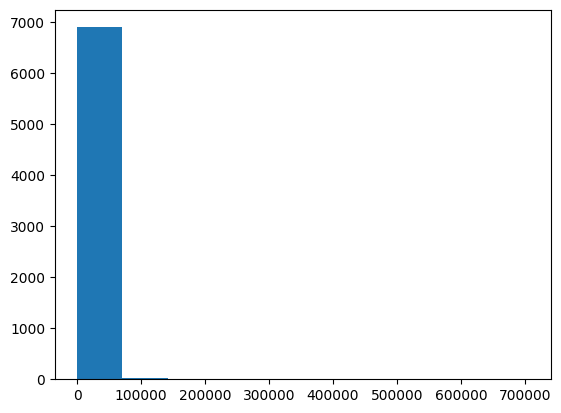

In [25]:
plt.hist(lengths)

# Create Text Field

In [26]:
for d in data:
    d["text"] = (
        f"{d['page']}\n"
        f"{d['section']}\n\n"
        f"{d['content']}"
    )

In [27]:
len(data)

6932

In [28]:
data[0]['content']

'Anthony Edward "Tony" Stark was the son of Howard and Maria Stark, a billionaire industrialist, the former CEO of Stark Industries, and a founding member of the Avengers. A brash but brilliant inventor, Stark was self-described as a genius, billionaire, playboy, and philanthropist. With his great wealth and exceptional technical knowledge, Stark was one of the world\'s most powerful men following the deaths of his parents and enjoyed the playboy lifestyle for many years until he was kidnapped by the Ten Rings in Afghanistan, while demonstrating a fleet of Jericho missiles. With his life on the line, Stark created an armored suit which he used to escape his captors. Upon returning home, he utilized several more armors to use against terrorists, as well as Obadiah Stane who turned against Stark. Following his fight against Stane, Stark publicly revealed himself as Iron Man.\n\nFresh off from defeating enemies all over the world, Stark found himself dying due to his own Arc Reactor poiso

In [30]:
# with open(OUTPUT_DIR/"final_clean_data.json", "w", encoding="utf-8") as f:
#     json.dump(data, f, indent=2, ensure_ascii=False)